In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

(20, 11)
Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')
0                  Mass (10^24kg)
1                   Diameter (km)
2                Density (kg/m^3)
3                 Gravity (m/s^2)
4          Escape Velocity (km/s)
5         Rotation Period (hours)
6           Length of Day (hours)
7     Distance from Sun (10^6 km)
8            Perihelion (10^6 km)
9              Aphelion (10^6 km)
10          Orbital Period (days)
11        Orbital Velocity (km/s)
12      Orbital Inclination (deg)
13           Orbital Eccentricity
14       Obliquity to Orbit (deg)
15           Mean Temperature (C)
16        Surface Pressure (bars)
17                Number of Moons
18                   Ring System?
19         Global Magnetic Field?
Name: Attribute, dtype: object
(21, 11)
41276.70608939402


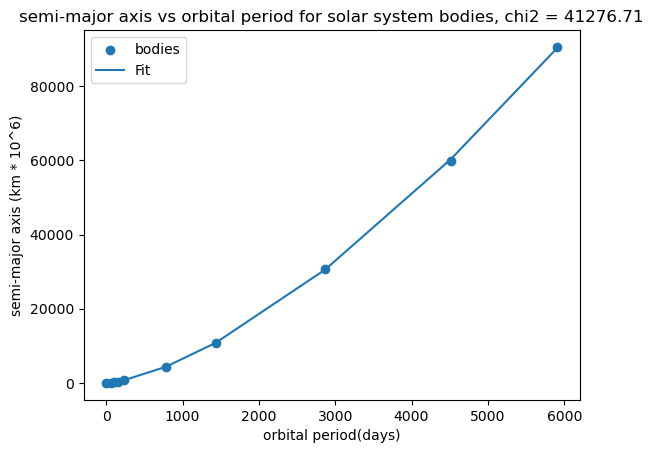

y = [0.2] * x ^ 1.5


In [50]:
df = pd.read_csv("solar_system.csv")
print(df.shape)
#2d dataframe with 20 rows, 11 columns
df.head(5)
df.tail(5)
print(df.columns)
print(df.iloc[:, 0])
orbital_period = df.iloc[10, 1:].astype(float)
perihelion = df.iloc[8, 1:].astype(float)
aphelion = df.iloc[9, 1:].astype(float)
#perihelion is the short end of the ellipse of the orbit, aphelion is the long end, and semi-major axis is the average.
semi_major_axis = (perihelion + aphelion) / 2
sm_axis_series = pd.Series(semi_major_axis)
df = pd.concat([df, sm_axis_series.to_frame().T], ignore_index=True)
print(df.shape)
#now 21x11

def keplers_third_law(a, m):
    return m * a ** 1.5

popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period)

residuals = orbital_period - keplers_third_law(semi_major_axis, popt)
chi2 = np.sum(residuals**2)
dof = len(semi_major_axis) - len(popt)
chi2_reduced = chi2 / dof
print(chi2_reduced)

plt.plot()
plt.scatter(semi_major_axis, orbital_period, label = "bodies")
plt.plot(semi_major_axis, keplers_third_law(semi_major_axis, popt), label = "Fit")
plt.xlabel("orbital period(days)")
plt.ylabel("semi-major axis (km * 10^6)")
plt.title(f"semi-major axis vs orbital period for solar system bodies, chi2 = {chi2_reduced:.2f}")
plt.legend()
plt.show()

rounded_popt = np.round(popt, 2)

print(f"y = {rounded_popt} * x ^ 1.5")

df.to_csv("kepler.csv", index = False)

